In [13]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

print("Added to path:", PROJECT_ROOT)


Added to path: C:\Users\keshav bansal\PycharmProjects\PythonProject2\Satellite-Imagery-Based-Property-Valuation


In [14]:
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from src.datasets import MultimodalDataset
from src.models import MultimodalRegressor


In [15]:
IMAGE_DIR = "../images/train"
CSV_PATH = "../data/raw/train.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [16]:
df = pd.read_csv(CSV_PATH)

df["log_price"] = np.log1p(df["price"])
df["image_id"] = df.index
# Cap extreme values
df["sqft_living_capped"] = df["sqft_living"].clip(upper=5000)

# House age
df["house_age"] = 2025 - df["yr_built"]

# Bathroom per bedroom ratio
df["bathroom_per_bedroom"] = df["bathrooms"] / (df["bedrooms"] + 1)
def has_image(image_id):
    return os.path.exists(os.path.join(IMAGE_DIR, f"{image_id}.png"))

df_valid = df[df["image_id"].apply(has_image)].copy()
df_valid = df_valid.reset_index(drop=True)

print("Valid samples:", len(df_valid))


Valid samples: 16201


In [17]:
TABULAR_FEATURES = [
    "bedrooms", "bathrooms", "sqft_living_capped", "sqft_lot",
    "sqft_living15", "sqft_lot15", "floors", "waterfront",
    "view", "condition", "grade", "lat", "long",
    "house_age", "bathroom_per_bedroom"
]
missing = [f for f in TABULAR_FEATURES if f not in df_valid.columns]
print("Missing features:", missing)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_valid[TABULAR_FEATURES] = scaler.fit_transform(
    df_valid[TABULAR_FEATURES]
)


Missing features: []


In [18]:
train_df, val_df = train_test_split(
    df_valid, test_size=0.2, random_state=42
)


In [19]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# Ensure tabular features are numeric
df_valid[TABULAR_FEATURES] = df_valid[TABULAR_FEATURES].astype(np.float32)

# Optional sanity check
print(df_valid[TABULAR_FEATURES].dtypes)
print(df_valid["log_price"].describe())


bedrooms                float32
bathrooms               float32
sqft_living_capped      float32
sqft_lot                float32
sqft_living15           float32
sqft_lot15              float32
floors                  float32
waterfront              float32
view                    float32
condition               float32
grade                   float32
lat                     float32
long                    float32
house_age               float32
bathroom_per_bedroom    float32
dtype: object
count    16201.000000
mean        13.045115
std          0.523875
min         11.225257
25%         12.676079
50%         13.017005
75%         13.369225
max         15.856731
Name: log_price, dtype: float64


In [20]:
train_dataset = MultimodalDataset(
    train_df, IMAGE_DIR, TABULAR_FEATURES, image_transform
)
val_dataset = MultimodalDataset(
    val_df, IMAGE_DIR, TABULAR_FEATURES, image_transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
img, tab, y = train_dataset[0]
print(tab)
print(tab.dtype)


tensor([-1.4655, -1.4545, -1.3390, -0.2485, -0.7381, -0.2256, -0.9188, -0.0838,
        -0.3069,  0.9090, -1.4115, -0.3625, -1.2351,  0.5161, -0.9890])
torch.float32


In [21]:
model = MultimodalRegressor(tabular_dim=len(TABULAR_FEATURES))
model = model.to(device)


C:\Users\keshav bansal\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\keshav bansal\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [22]:
criterion = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    list(model.tabular_mlp.parameters()) +
    list(model.regressor.parameters()),
    lr=3e-4
)


In [23]:
def train_one_epoch(model, loader):
    model.train()
    losses = []

    for images, tabular, targets in loader:
        images = images.to(device)
        tabular = tabular.to(device)
        targets = targets.to(device)

        preds = model(images, tabular)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)


def evaluate(model, loader):
    model.eval()
    preds_all, targets_all = [], []

    with torch.no_grad():
        for images, tabular, targets in loader:
            images = images.to(device)
            tabular = tabular.to(device)
            targets = targets.to(device)

            preds = model(images, tabular)
            preds_all.append(preds.cpu().numpy())
            targets_all.append(targets.cpu().numpy())

    preds_all = np.concatenate(preds_all)
    targets_all = np.concatenate(targets_all)

    rmse = np.sqrt(mean_squared_error(targets_all, preds_all))
    r2 = r2_score(targets_all, preds_all)

    return rmse, r2


In [24]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_rmse, val_r2 = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R2: {val_r2:.4f}"
    )


Epoch 1 | Train Loss: 3.6352 | Val RMSE: 0.9052 | Val R2: -2.0080
Epoch 2 | Train Loss: 0.4627 | Val RMSE: 0.5372 | Val R2: -0.0591
Epoch 3 | Train Loss: 0.2021 | Val RMSE: 0.4529 | Val R2: 0.2470
Epoch 4 | Train Loss: 0.1342 | Val RMSE: 0.3592 | Val R2: 0.5265
Epoch 5 | Train Loss: 0.1032 | Val RMSE: 0.3265 | Val R2: 0.6088
Epoch 6 | Train Loss: 0.0899 | Val RMSE: 0.3225 | Val R2: 0.6183
Epoch 7 | Train Loss: 0.0828 | Val RMSE: 0.2706 | Val R2: 0.7312
Epoch 8 | Train Loss: 0.0754 | Val RMSE: 0.3216 | Val R2: 0.6203
Epoch 9 | Train Loss: 0.0729 | Val RMSE: 0.2746 | Val R2: 0.7231
Epoch 10 | Train Loss: 0.0651 | Val RMSE: 0.2481 | Val R2: 0.7740


In [25]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

In [36]:
model.eval()

for param in model.image_encoder.cnn.parameters():
    param.requires_grad = True


In [37]:
model.image_encoder.cnn.layer4


Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1

In [43]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer = model.image_encoder.cnn.layer4

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image, tabular):
        self.model.zero_grad()

        output = self.model(image, tabular)
        output.backward()

        # SAFETY CHECK
        assert self.gradients is not None, "Gradients are None — CNN not receiving gradients"

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = cam[0].detach().cpu().numpy()
        cam = cv2.resize(cam, (256, 256))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam


In [67]:
idx = 100 # try multiple later

img_path = f"{IMAGE_DIR}/{val_df.index[idx]}.png"
image = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_tensor = transform(image).unsqueeze(0).to(device)

tabular_tensor = torch.tensor(
    val_df.loc[val_df.index[idx], TABULAR_FEATURES]
        .astype("float32")
        .values,
    dtype=torch.float32
).unsqueeze(0).to(device)


In [68]:
gradcam = GradCAM(model)

cam = gradcam.generate(image_tensor, tabular_tensor)

print(cam.shape)  # (256, 256)


(256, 256)


C:\Users\keshav bansal\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


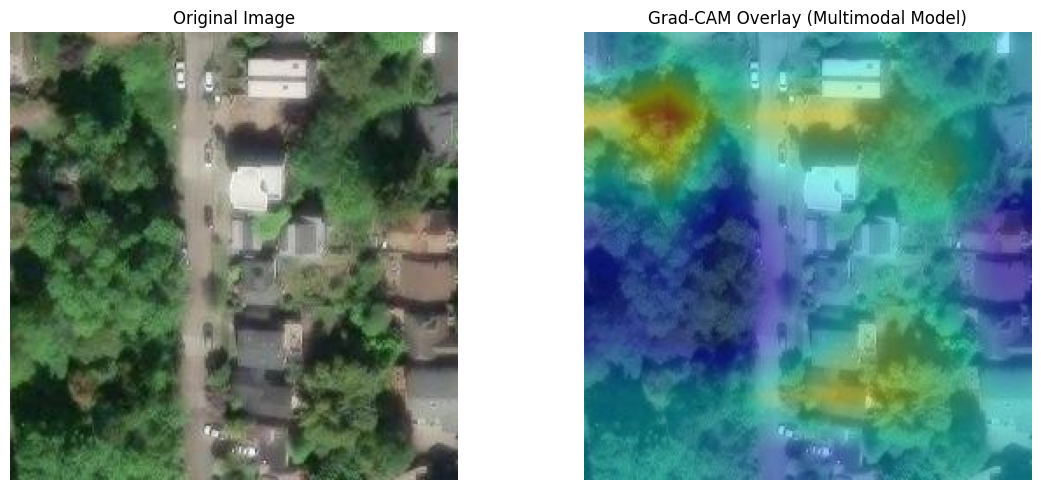

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Original image (for display)
orig_img = np.array(image.resize((256, 256))) / 255.0

# Grad-CAM heatmap (already computed)
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = heatmap[..., ::-1] / 255.0  # BGR → RGB

# Overlay
overlay = 0.6 * orig_img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

# Plot side-by-side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(orig_img)
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM Overlay (Multimodal Model)")

plt.tight_layout()
plt.show()
